In [ ]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt

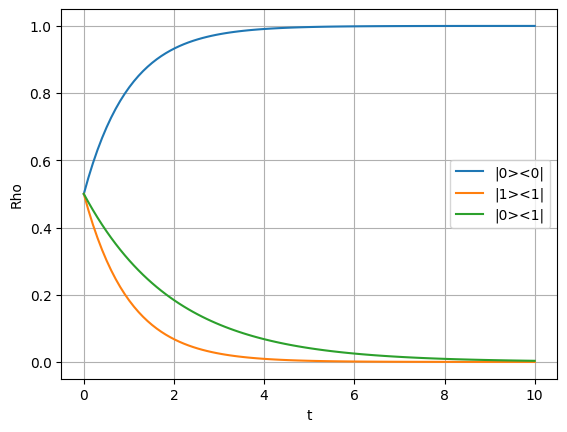

In [69]:
#1qubit

# Parametry
omega = 0.0
gamma = 1.0

# Operatory
sz = sigmaz()
sm = sigmap()

# Hamiltonian
H = 0.5 * omega * sz

# Operatory Lindblada
c_ops = [np.sqrt(gamma) * sm]

# Stan początkowy jako MACIERZ GĘSTOŚCI
psi = basis(2, 1) + basis(2, 0)
psi = psi.unit()
rho0 = psi * psi.dag()

# Czas
tlist = np.linspace(0, 10, 100)

# Rozwiązanie (UWAGA: brak e_ops → dostajemy stany)
result = mesolve(H, rho0, tlist, c_ops, [])

# Lista macierzy gęstości
rho_t = result.states

# ----------------------------
# Populations
# ----------------------------
rho_np = np.array([rho.full() for rho in rho_t])
pop_0 = np.abs(rho_np[:, 0, 0])
pop_1 = np.abs(rho_np[:, 1, 1])
coh_01 = np.abs(rho_np[:, 0, 1])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(tlist, pop_0, label='|0><0|')
ax.plot(tlist, pop_1, label='|1><1|')
ax.plot(tlist, coh_01, label='|0><1|')
ax.set_xlabel("t")
ax.set_ylabel("Rho")
ax.legend()
ax.grid(True)
plt.show()

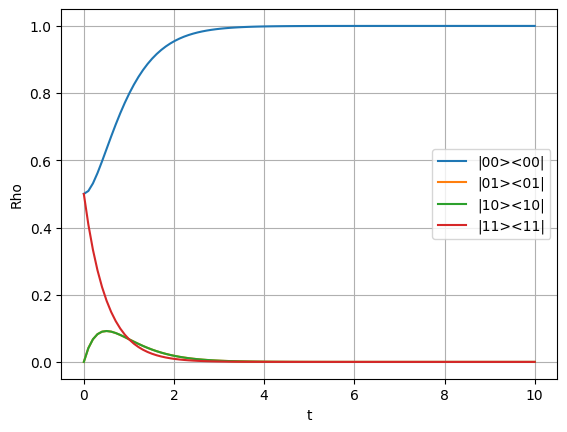

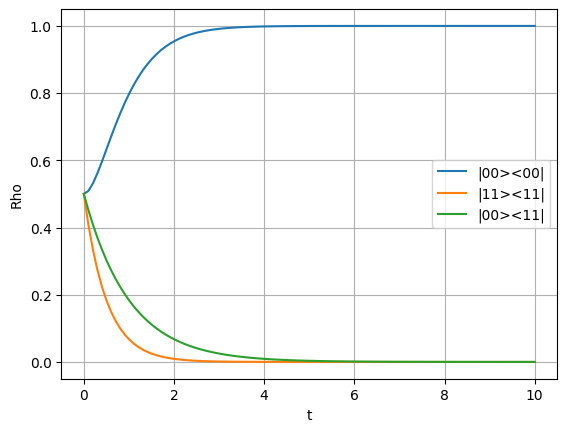

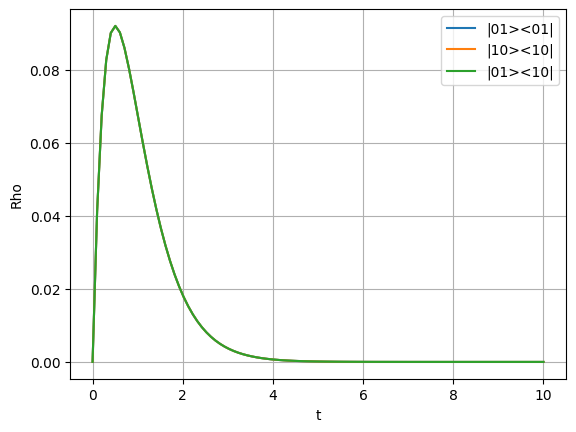

In [87]:
#2qubity

# Parametry
omega = 0.0
gamma1 = 0.0
gamma2 = 1.0

# Operatory
sz = sigmaz()
sm = sigmap()
eye = qeye(2)

# Hamiltonian
H = 0.5 * omega * tensor(sz,sz)

# Operatory Lindblada
L_coll = np.sqrt(gamma2) * (tensor(sm, eye) + tensor(eye, sm))
L1 = np.sqrt(gamma1) * tensor(eye, sm)
L2 = np.sqrt(gamma1) * tensor(sm, eye)
c_ops = [L1, L2, L_coll]

# Stan początkowy jako MACIERZ GĘSTOŚCI
# pojedyncze qubity
q0 = basis(2,0)  # |0>
q1 = basis(2,1)  # |1>

# superpozycja Bell |Φ+> = (|00> + |11>)/√2
bell_phi_plus = (tensor(q0,q0) + tensor(q1,q1)).unit()
rho0 = bell_phi_plus * bell_phi_plus.dag()

# Czas
tlist = np.linspace(0, 10, 100)

# Rozwiązanie (UWAGA: brak e_ops → dostajemy stany)
result = mesolve(H, rho0, tlist, c_ops, [])

# Lista macierzy gęstości
rho_t = result.states



# ----------------------------
# Populations
# ----------------------------
rho_np = np.array([rho.full() for rho in rho_t])
pop_00 = np.abs(rho_np[:, 0, 0])
pop_01 = np.abs(rho_np[:, 1, 1])
pop_10 = np.abs(rho_np[:, 2, 2])
pop_11 = np.abs(rho_np[:, 3, 3])
coh_0011 = np.abs(rho_np[:, 0, 3])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(tlist, pop_00, label='|00><00|')
ax.plot(tlist, pop_01, label='|01><01|')
ax.plot(tlist, pop_10, label='|10><10|')
ax.plot(tlist, pop_11, label='|11><11|')
ax.set_xlabel("t")
ax.set_ylabel("Rho")
ax.legend()
ax.grid(True)
plt.show()

# ----------------------------
# Coherences|00><11|
# ----------------------------
rho_np = np.array([rho.full() for rho in rho_t])
pop_00 = np.abs(rho_np[:, 0, 0])
pop_01 = np.abs(rho_np[:, 1, 1])
pop_10 = np.abs(rho_np[:, 2, 2])
pop_11 = np.abs(rho_np[:, 3, 3])
coh_0011 = np.abs(rho_np[:, 0, 3])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(tlist, pop_00, label='|00><00|')
ax.plot(tlist, pop_11, label='|11><11|')
ax.plot(tlist, coh_0011, label='|00><11|')
ax.set_xlabel("t")
ax.set_ylabel("Rho")
ax.legend()
ax.grid(True)
plt.show()

# ----------------------------
# Coherences|01><10|
# ----------------------------
rho_np = np.array([rho.full() for rho in rho_t])
pop_01 = np.abs(rho_np[:, 1, 1])
pop_10 = np.abs(rho_np[:, 2, 2])
coh_0110 = np.abs(rho_np[:, 1, 2])

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(tlist, pop_01, label='|01><01|')
ax.plot(tlist, pop_10, label='|10><10|')
ax.plot(tlist, coh_0110, label='|01><10|')
ax.set_xlabel("t")
ax.set_ylabel("Rho")
ax.legend()
ax.grid(True)
plt.show()